# Output-calibration VALIDATION

Validates the **applied** sensor cal (derived from the phased ≥5-run calibration) on
**independent** data — never the calibration set:

1. **Multisine maneuver** (1 run) — all axes excited together at distinct frequencies, so it
   tests the cal's cross-axis **coupling** terms that phased single-axis derivation can't self-check.
2. **Landing to touchdown** (1 run) — the real operating regime (descent, low alt, marker→ring handoff).

Both compare the **calibrated** corner + ring flow against **Gazebo GT** (GT-direct only; the
corner-as-transfer-standard trick is a derivation expedient, not a validation). The cal is
auto-loaded from `src/img_data.py`, so this always reflects what the runtime actually applies.

> 1 run is enough to validate the **signal** (R²/tracking). Landing **performance** (xy/softness)
> is a different question that needs n≥5.

In [1]:
import os, sys, glob, numpy as np, matplotlib.pyplot as plt, datetime as _dt
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'tools'))
import validate_output_flow as vft   # gt_v_flow, best_offset, validate, CAL, CAL_RING

# Pick which validation runs to load (0 = latest, 1 = previous, ...). The picker
# lists ALL runs in each folder so you can access any of them; set the *_INDEX.
MULTISINE_INDEX = 0
LANDING_INDEX   = 0
N_SHOW = 25

def _list_runs(pats):
    runs = {}
    for pat in pats:
        for d in glob.glob(pat):
            if os.path.isdir(d) and os.path.isfile(os.path.join(d, 'Img_Data.npy')):
                runs[d] = os.path.getmtime(d)
    return sorted(runs.items(), key=lambda kv: -kv[1])      # most recent first

def _pick(name, primary_pats, fallback_pats, index):
    runs = _list_runs(primary_pats)
    src = 'validation_data'
    if not runs:                                   # only fall back when no validation run exists
        runs = _list_runs(fallback_pats); src = 'fallback (NOT independent)'
    print(f'{name} runs [{src}] (most recent first; pick via {name}_INDEX):')
    for i, (d, mt) in enumerate(runs[:N_SHOW]):
        mark = '  <-- CURRENT' if i == index else ''
        print(f'  [{i:2d}] {_dt.datetime.fromtimestamp(mt):%Y-%m-%d %H:%M:%S}  {os.path.basename(d)}{mark}')
    if len(runs) > N_SHOW: print(f'  ... and {len(runs) - N_SHOW} older')
    if not runs: print('  (none found)'); return None
    return runs[min(index, len(runs) - 1)][0]

MULTISINE_RUN = _pick('MULTISINE', ['../validation_data/multisine/*'],
                      ['../calibration_data/output/*'], MULTISINE_INDEX)
print()
LANDING_RUN   = _pick('LANDING', ['../validation_data/landing/*'],
                      ['../test_data/Landing_Test/*', '../test_data/RingFlow/*'], LANDING_INDEX)
print('\nMULTISINE_RUN =', MULTISINE_RUN)
print('LANDING_RUN   =', LANDING_RUN)

MULTISINE runs [validation_data] (most recent first; pick via MULTISINE_INDEX):
  [ 0] 2026-06-07 00:03:52  Sun Jun  7 00-01-07 2026  <-- CURRENT
  [ 1] 2026-06-06 21:54:02  Sat Jun  6 21-51-19 2026
  [ 2] 2026-06-06 21:42:27  Sat Jun  6 21-39-44 2026
  [ 3] 2026-06-06 20:40:51  Sat Jun  6 20-38-04 2026

LANDING runs [validation_data] (most recent first; pick via LANDING_INDEX):
  [ 0] 2026-06-07 00:08:42  Sun Jun  7 00-08-38 2026  <-- CURRENT
  [ 1] 2026-06-05 15:35:39  Fri Jun  5 15-35-38 2026

MULTISINE_RUN = ../validation_data/multisine/Sun Jun  7 00-01-07 2026
LANDING_RUN   = ../validation_data/landing/Sun Jun  7 00-08-38 2026


In [2]:
# Applied cal (auto-loaded from src/img_data.py via the validate tool)
print('corner _sensor_cal_hw diag :', np.round(np.diag(vft.CAL), 4))
print('ring   _sensor_cal_ring diag:', np.round(np.diag(vft.CAL_RING), 4),
      '(identity =', np.allclose(vft.CAL_RING, np.eye(6)), ')')

def r2(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 8: return np.nan
    return 1 - np.sum((a[m]-b[m])**2) / (np.sum((b[m]-b[m].mean())**2) + 1e-12)
CHN = ['h_x', 'h_y', 'h_z', 'w_x', 'w_y', 'w_z']

corner _sensor_cal_hw diag : [0.9791 0.917  1.1119 0.     0.     1.0647]
ring   _sensor_cal_ring diag: [1.1025 0.6537 1.3463 0.     0.     3.451 ] (identity = False )


## 1 — Multisine validation: FUSED-EKF flow vs GT  (EKF-FOCUSED)

The fused corner+ring **EKF** target-relative `[h_tr; w]` is the headline calibrated output
(`FLOW_FUSE_RING=1`). Per-channel R² for corner / ring / EKF is printed first, then the **EKF**
plot (headline), then corner & ring as the EKF's input components.

In [3]:
# Shared vft.prep() (one source of truth with validate()); per-channel R^2 corner/ring/EKF.
P = vft.prep(MULTISINE_RUN)
ch = vft.channel_r2(P)                       # prints per-channel R^2: corner / ring / EKF
CHN = ['h_x', 'h_y', 'h_z', 'w_x', 'w_y', 'w_z']

=== Sun Jun  7 00-01-07 2026 ===  align r=0.99, off=+14.9s
  estimator       hx       hy       hz       wx       wy       wz
     corner     0.68     0.55     0.98     1.00     1.00     0.85
       ring     0.46     0.69     0.78     1.00     1.00     0.75
        EKF     0.78     0.69     0.99     1.00     1.00     0.86


### EKF FUSED `[h_tr; w]` vs GT — the headline output

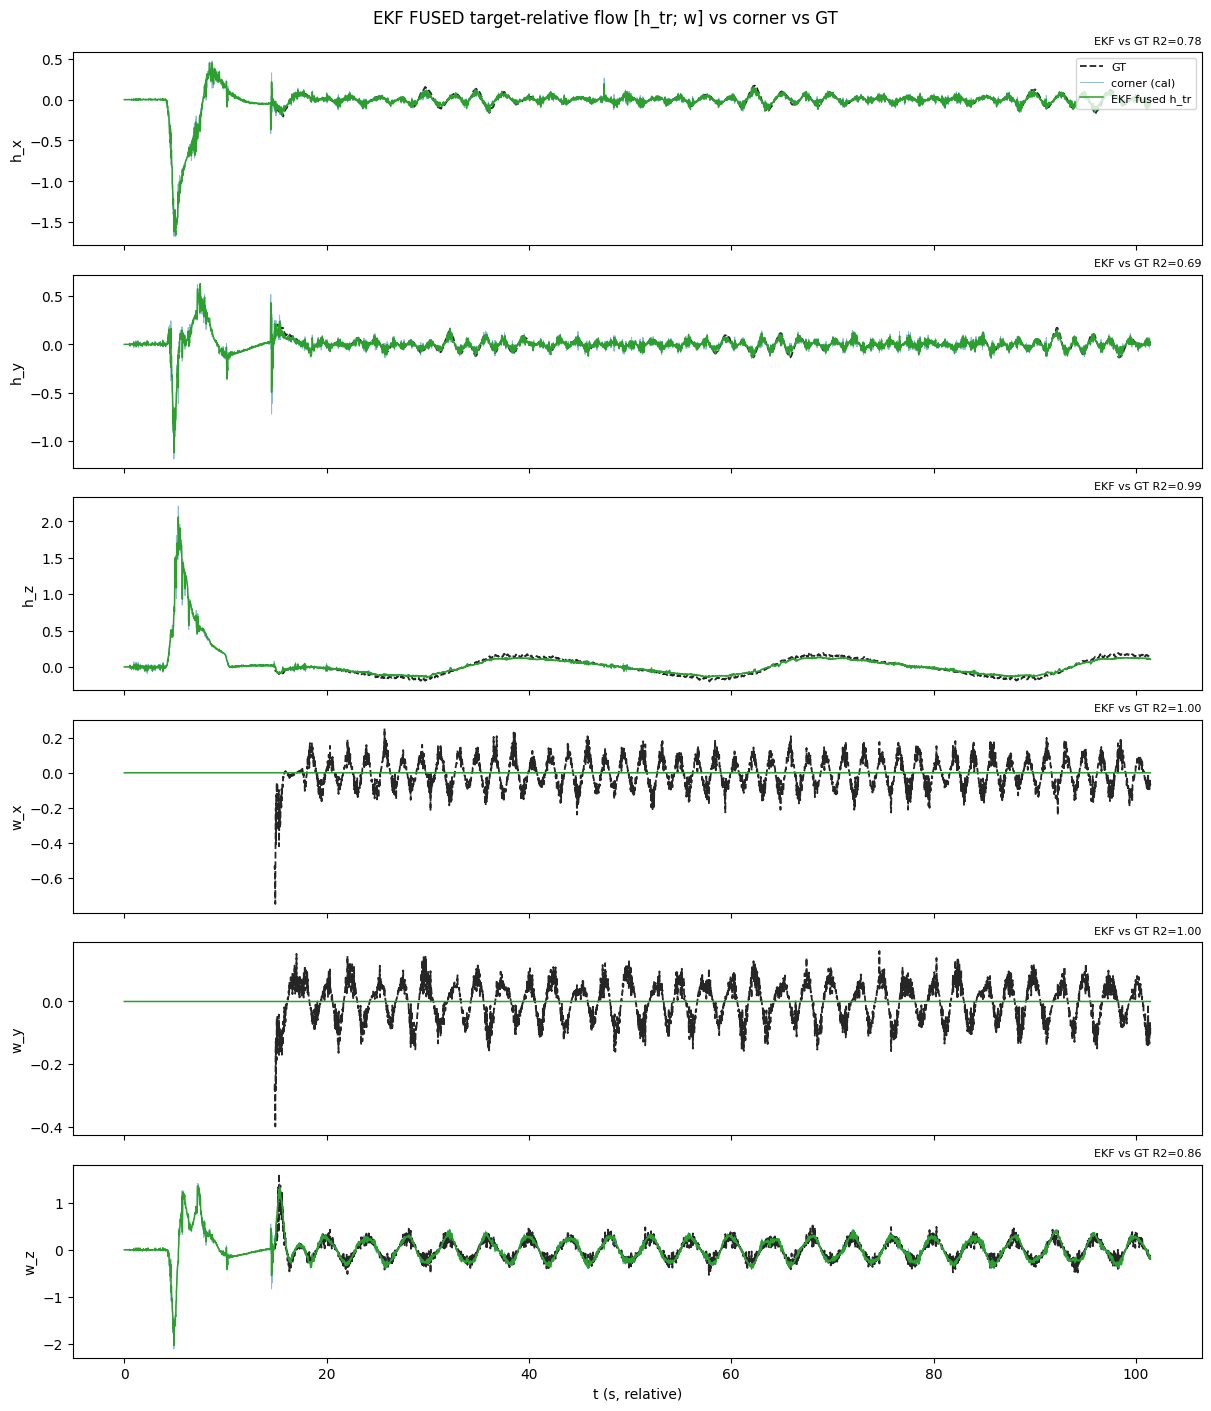

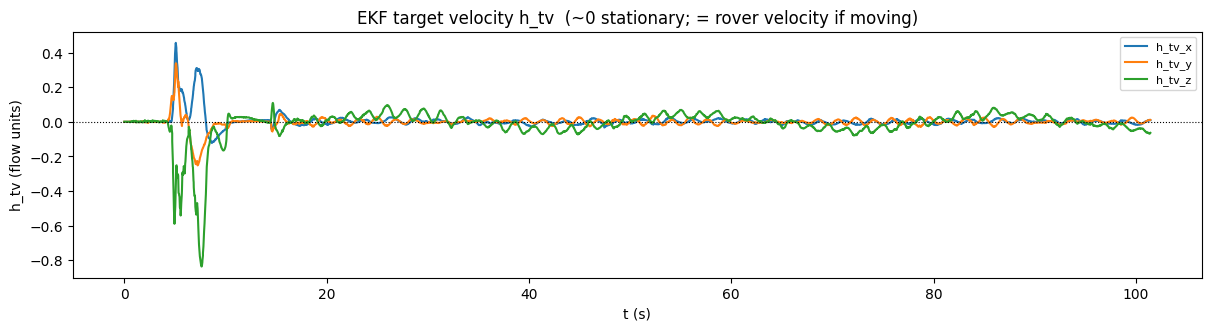

In [4]:
# EKF fused (target-relative [h_tr; w]) via the same P — needs a FLOW_FUSE_RING=1 recording
if P['fused'] is None:
    print("No EKF fused data in this run — record with FLOW_FUSE_RING=1.")
else:
    fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True, constrained_layout=True)
    for i, name in enumerate(CHN):
        ax = axes[i]
        ax.plot(P['ti_r'], P['GTi'][:, i], 'k--', lw=1.3, alpha=0.85, label='GT')
        cm = P['ncc'] > 0; ax.plot(P['ti_r'][cm], P['corn_cal'][cm, i], 'C0', lw=0.7, alpha=0.5, label='corner (cal)')
        ax.plot(P['ti_r'], P['fused'][:, i], 'C2', lw=1.1, label='EKF fused h_tr')
        ax.set_ylabel(name); ax.set_title(f"EKF vs GT R2={vft.r2_slope(P['fused'][:, i], P['GTi'][:, i])[0]:.2f}", fontsize=8, loc='right')
        if i == 0: ax.legend(fontsize=8, loc='upper right')
    axes[-1].set_xlabel('t (s, relative)')
    fig.suptitle('EKF FUSED target-relative flow [h_tr; w] vs corner vs GT', fontsize=12); plt.show()
    if P['target_vel'] is not None:
        tv = P['target_vel']
        fig, ax = plt.subplots(1, 1, figsize=(12, 3.2), constrained_layout=True)
        for k, lab in enumerate(['x', 'y', 'z']): ax.plot(P['ti_r'], tv[:, k], label=f'h_tv_{lab}')
        ax.axhline(0, color='k', ls=':', lw=0.8); ax.set_xlabel('t (s)'); ax.set_ylabel('h_tv (flow units)')
        ax.set_title('EKF target velocity h_tv  (~0 stationary; = rover velocity if moving)')
        ax.legend(fontsize=8); plt.show()

### Components — corner + ring (cal) vs GT  (the EKF's inputs)

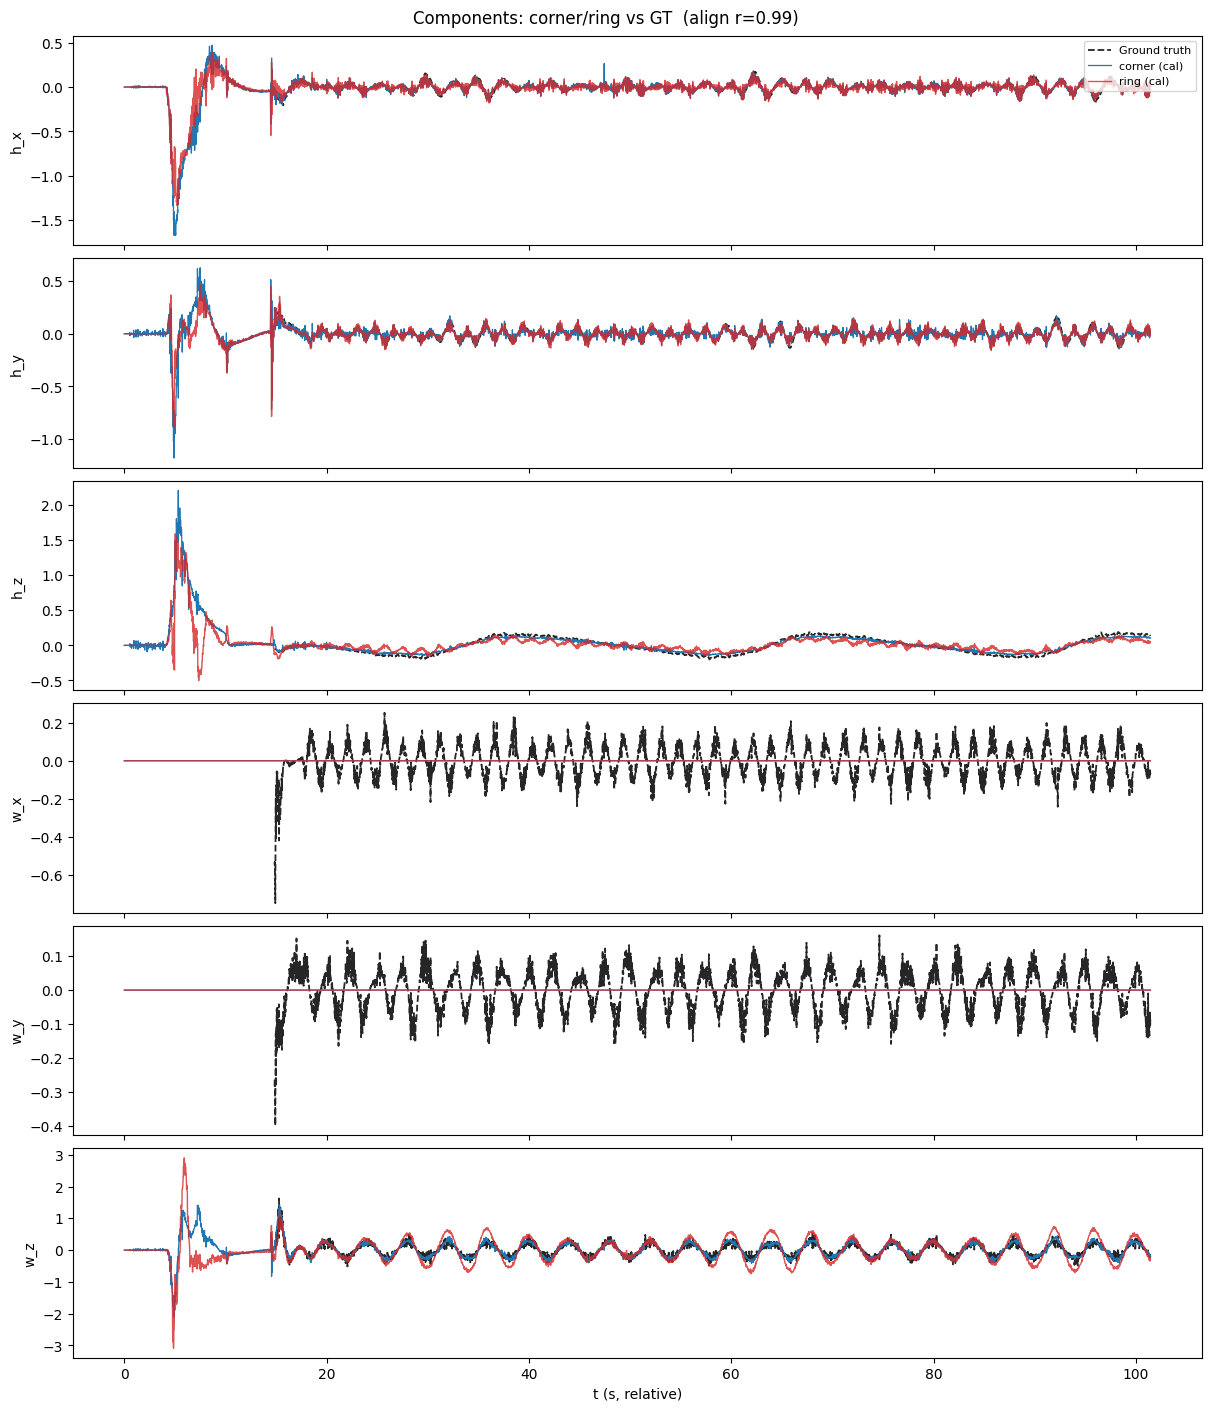

In [5]:
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True, constrained_layout=True)
for i, name in enumerate(CHN):
    ax = axes[i]
    ax.plot(P['ti_r'], P['GTi'][:, i], 'k--', lw=1.3, alpha=0.85, label='Ground truth')
    cm = P['ncc'] > 0; ax.plot(P['ti_r'][cm], P['corn_cal'][cm, i], 'C0', lw=0.9, label='corner (cal)')
    rm = P['ncr'] > 0; ax.plot(P['ti_r'][rm], P['ring_cal'][rm, i], 'C3', lw=1.0, alpha=0.8, label='ring (cal)')
    ax.set_ylabel(name)
    if i == 0: ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('t (s, relative)')
fig.suptitle(f"Components: corner/ring vs GT  (align r={P['align_r']:.2f})", fontsize=12)
plt.show()

## 2 — Landing-to-touchdown validation

Runs `validate_flow_to_touchdown.validate()` on the landing run: ring R²/slope binned by
**altitude** into the final 0.0–0.2 m, marker→ring switch continuity, and the ω sign-check.
This is the cal in its real regime.

=== Sun Jun  7 00-08-38 2026 ===  img 5504f, GT 14669f
alignment: offset +12.45s (corner-div vs GT-div corr r=0.89); GT h ungated to touchdown

(i) RING V_v_ring (_sensor_cal_ring) vs GT V-frame flow, binned by ALTITUDE  [R^2 | slope]
  altitude  nfr           h_x           h_y      h_z(div)           w_x           w_y           w_z
  9.0-1.0m 4860   0.45| 0.56  0.69| 0.80  0.42| 0.44  1.00| 0.00  1.00| 0.00  0.00| 0.04
  1.0-0.5m    0    nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan
  0.5-0.2m    0    nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan
  0.2-0.0m    0    nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan   nan|  nan
  final 0.2-0.0m bin = to touchdown. R^2->1 slope->1 = tracks truth there.

(ii) SWITCH continuity: corner V_v vs ring V_v_ring (overlap) — the GT-free bug-check
  overlap 5504/5504         comp  R2 raw  R2 savgol slope_savgol
                           h_x    0.95       0.96         0.71
                   

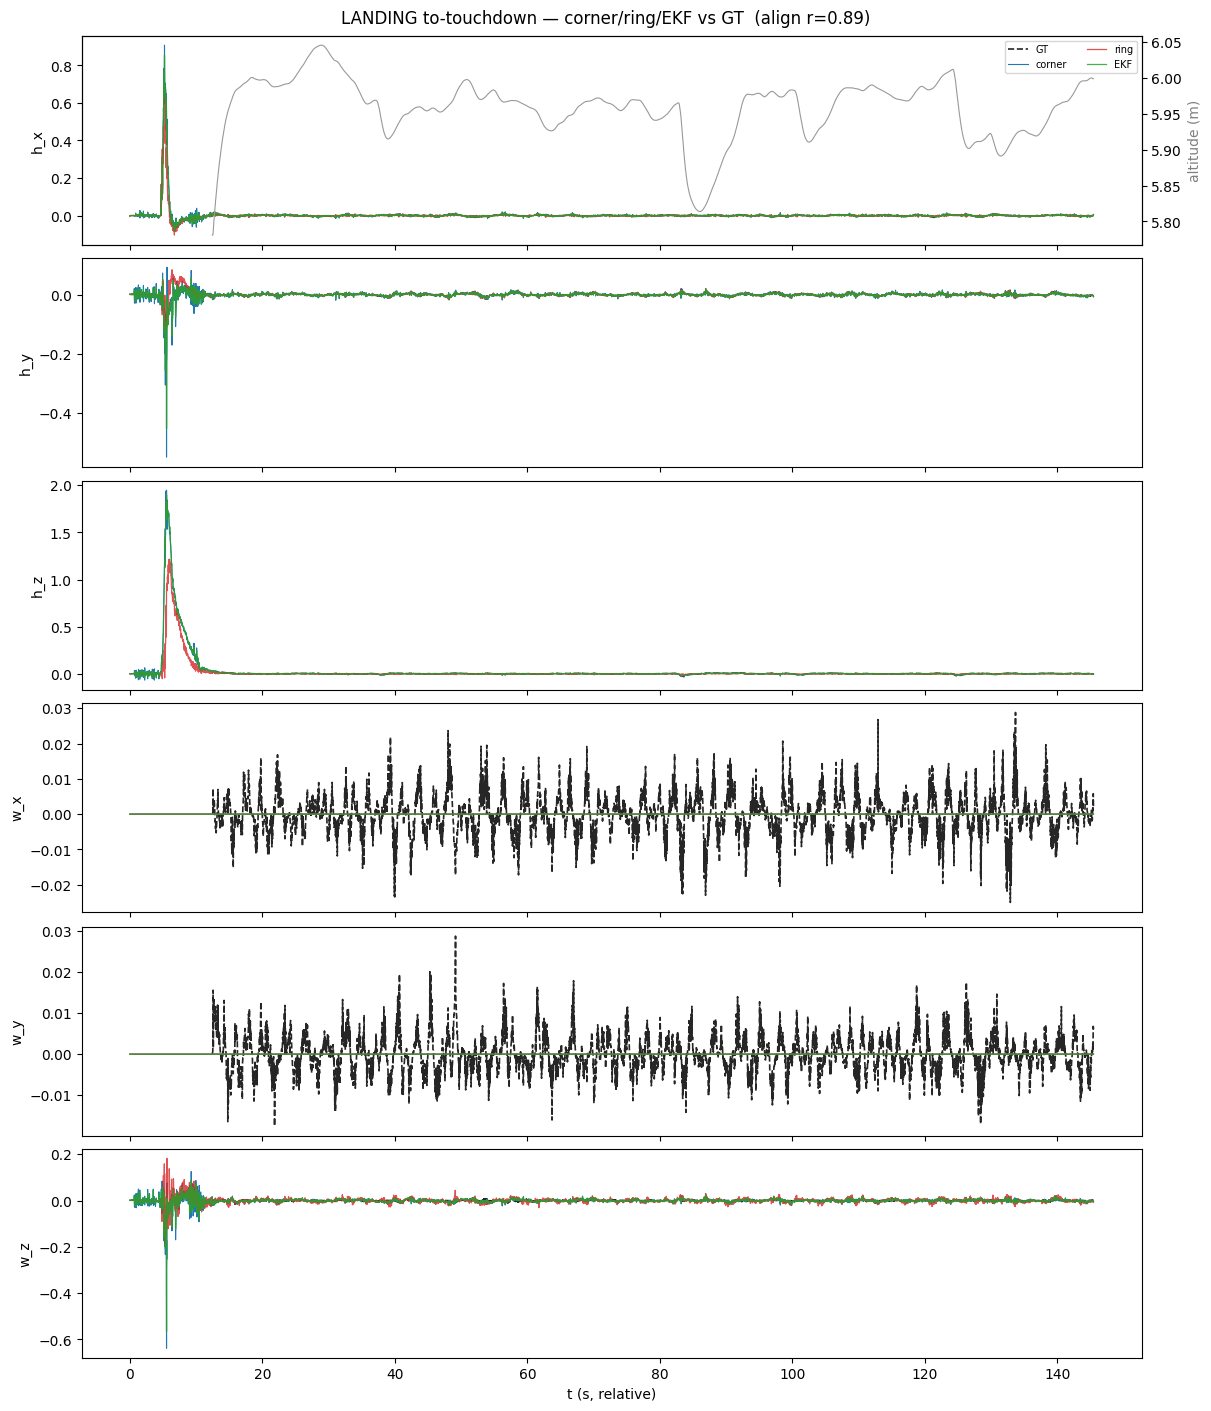

In [6]:
if not LANDING_RUN:
    print('No landing run found.')
else:
    # to-touchdown table (altitude-binned, GT-direct)
    try:
        vft.validate(LANDING_RUN)
    except (KeyError, FileNotFoundError) as e:
        print(f'validate() table unavailable ({e})')
    # ...and the matching PLOT via the shared prep(): corner/ring/EKF vs GT over the descent,
    # with altitude overlaid so you can read the to-touchdown behaviour.
    PL = vft.prep(LANDING_RUN)
    t = PL['ti_r']; CHN = ['h_x', 'h_y', 'h_z', 'w_x', 'w_y', 'w_z']
    fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True, constrained_layout=True)
    for i, name in enumerate(CHN):
        ax = axes[i]
        ax.plot(t, PL['GTi'][:, i], 'k--', lw=1.2, alpha=0.85, label='GT')
        cm = PL['ncc'] > 0; ax.plot(t[cm], PL['corn_cal'][cm, i], 'C0', lw=0.8, label='corner')
        rm = PL['ncr'] > 0; ax.plot(t[rm], PL['ring_cal'][rm, i], 'C3', lw=0.9, alpha=0.8, label='ring')
        if PL['fused'] is not None:
            ax.plot(t, PL['fused'][:, i], 'C2', lw=0.9, alpha=0.85, label='EKF')
        ax.set_ylabel(name)
        if i == 0: ax.legend(fontsize=7, loc='upper right', ncol=2)
    axt = axes[0].twinx(); axt.plot(t, PL['Vz_i'], color='0.6', lw=0.8)
    axt.set_ylabel('altitude (m)', color='0.5')
    axes[-1].set_xlabel('t (s, relative)')
    fig.suptitle(f"LANDING to-touchdown — corner/ring/EKF vs GT  (align r={PL['align_r']:.2f})", fontsize=12)
    plt.show()